# Notebook 07 - Market Basket Analysis

**Input:** `data/interim/transactions_clean.parquet` (1.04M rows, ~39K invoices, ~4,900 products)

**Output:**
- `data/processed/product_rules.parquet` - association rules with support, confidence, lift
- `data/processed/product_cross_sell.parquet` - top cross-sell recommendations per product
- `reports/figures/basket_*.png` - visualizations

## Why pivot from customer-level to product-level

Notebook 04-06 built the **strategy matrix** - who to target, when, and with what urgency. But that matrix doesn't answer one critical question: **what should we actually offer each customer?

Market basket analysis answers that. It finds products that are frequently purchased together, producing rules like:

> *Customers who buy the white t-light holder are 4x more likely to also buy the regency cakestand than a random shopper.*

Combined with the strategy matrix:
- Customer A is in "Urgent win-back" -> look at what they bought historically -> recommend the highest-lift complementary product -> personalized offer.

That's a complete recommendation: the right customer, the right product, the right time.

## The three core metrics

All of association rules mining boils down to 3 numbers:
1. **Support** = % of all invoices that contain item X (or both X and Y). Tells you how the common a pattern is.
2. **Confidence** = `P(X | Y)` = if someone buys X, what fraction also buy Y? Tells you how reliable the rule is.
3. **Lift** = `confidence / P(Y)` = how much MORE likely is Y given X, vs. a random shopper? **The single most important metric.** <br>
Lift > 1 = real association. Lift = 1 = independence (no signal). Lift < 1 = negative association.

Lift is what we'll rank by because confidence alone is misleading - a hugely popular product will have high confidence with everything else just because it's in everyrone's basket.

## Notebook structure:
1. Load and prepare transaction-level data
2. Filter products & invoices to a tracable subset
3. Build basket matrix (one-hot encoded baskets)
4. Run Apriori to find frequent itemsets
5. Generate association rule with support, confidence, lift
6. Inspect top rules
7. Build a per-product cross-sell lookup
8. Visualize the recommendation network
9. Save outputs for the recommendation engine

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.3f}'.format)
sns.set_style('whitegrid')

INTERIM_DIR = Path('../data/interim')
PROCESSED_DIR = Path('../data/processed')
REPORTS_DIR = Path('../reports/figures')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load transactions
We use `transactions_clean.parquet` (NOT the customer-level one). because market basket analysis is invoice-driven - guest checkouts contribute valid co-purchase signal even without a customer ID

In [5]:
df = pd.read_parquet(INTERIM_DIR / 'transactions_clean.parquet')
print(f'Loaded {len(df):,} rows across {df["Invoice"].nunique():,} invoices and {df["StockCode"].nunique():,} products')

Loaded 1,037,012 rows across 39,519 invoices and 4,897 products


## 2. Why filtering matters

**The comnbinatorial explosion problem:** with 4,899 unique products, there are 4899 x 4898 / 2 ≈ **12 million possible pairs,** and exponentially more triples and beyond. Apriori would take forever and memory on the full set.

**The solution:** keep only products that appear often enough to produce statistically reliable rules, and only invoices with enough items to actually form a basket. This inn't cheating - it's focusing the analysis on the products where reliable patterns can exist.

**Filters we'll apply:**
- Drop invoices with fewer than 2 distinct products (no basket = nothing to learn)
- Keep only products that appear in at least 1% of invoices (~396 invoices). Rare products = unreliable patterns.
- Cap basket size at the 95th percentile to prevent one huge wholesale order from skewing everything.

In [15]:
# Compute invoice-level basket sizes (unique products per invoice)
basket_sizes = df.groupby('Invoice')['StockCode'].nunique()

# Cap at 95th percentile to avoid one mega-order dominating
cap = int(basket_sizes.quantile(.95))
print(f'Basket size 95th percentile: {cap}')

valid_invoices = basket_sizes[(basket_sizes >= 2) & (basket_sizes <= cap)].index
print(f'Invoices kept (2 ≤ basket_size ≤ {cap}): {len(valid_invoices):,} of {df["Invoice"].nunique():,}')

# Filter
df_basket = df[df['Invoice'].isin(valid_invoices)].copy()

# Keep only products that appear in >= 1% of remaining invoices
min_invoice_count = max(int(0.01 * len(valid_invoices)), 50)
product_invoice_count = df_basket.groupby('StockCode')['Invoice'].nunique()
popular_products = product_invoice_count[product_invoice_count > min_invoice_count].index
print(f'\nProducts kept (≥{min_invoice_count} invoices): {len(popular_products):,} of {df["StockCode"].nunique():,}')

df_basket = df_basket[df_basket['StockCode'].isin(popular_products)].copy()
print(f'\nFiltered dataset: {len(df_basket):,} rows, {df_basket["Invoice"].nunique():,} invoices, {df_basket["StockCode"].nunique():,} products')

Basket size 95th percentile: 73
Invoices kept (2 ≤ basket_size ≤ 73): 34,374 of 39,519

Products kept (≥343 invoices): 527 of 4,897

Filtered dataset: 387,529 rows, 33,032 invoices, 527 products


## 3. Build the basket matrix
Apriori expects a **one-hot encoded** dataframe where:
- Each row = one invoice (basket)
- Each column = one product
- Each cell = 1 if the product is in the basket, 0 otherwise

Quantity doesn't matter for basket analysis - what matters is co-occurence. Buying 1 cakestand or 10 is the same signal: the cakestand was in the basket.

In [18]:
# Pivot to invoice x product, mark with 1 wherever present
basket = (df_basket.groupby(['Invoice','StockCode'])['Quantity'].sum().unstack(fill_value=0))

# Convert to boolean: was the product in this invoices?
basket_binary = (basket > 0).astype(bool)

print(f'Basket matrix: {basket_binary.shape[0]:,} invoices x {basket_binary.shape[1]:,} products')
print(f'Memory: {basket_binary.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
basket_binary.head(3)

Basket matrix: 33,032 invoices x 527 products
Memory: 17.0 MB


StockCode,15036,15056BL,15056N,16156S,16161P,20675,20676,20677,20679,20682,20685,20711,20712,20713,20717,20718,20719,20723,20724,20725,20726,20727,20728,20749,20750,20754,20828,20829,20914,20969,20970,20971,20972,20973,20974,20975,20979,20981,20982,20983,21033,21034,21035,21041,21078,21080,21086,21094,21098,21108,21114,21121,21122,21124,21136,21137,21154,21155,21156,21164,21165,21166,21169,21172,21174,21175,21181,21210,21212,21213,21216,21217,21218,21231,21232,21238,21239,21240,21242,21243,21244,21257,21258,21259,21260,21314,21326,21328,21380,21385,21390,21411,21428,21429,21430,21479,21481,21484,21485,21497,21498,21499,21500,21506,21507,21508,21509,21519,21523,21524,21527,21531,21533,21535,21539,21558,21559,21561,21592,21621,21622,21623,21658,21668,21669,21670,21671,21672,21673,21700,21703,21704,21714,21731,21733,21745,21754,21755,21756,21770,21790,21791,21843,21844,21868,21870,21871,21874,21876,21877,21888,21889,21890,21891,21892,21899,21900,21901,21907,21908,21912,21914,21915,21916,21918,21928,21929,21930,21931,21932,21933,21935,21936,21937,21955,21974,21975,21976,21977,21980,21982,21985,21989,22027,22029,22030,22037,22041,22045,22055,22059,22061,22064,22072,22077,22079,22080,22082,22083,22084,22086,22087,22088,22089,22090,22109,22111,22112,22113,22114,22131,22138,22139,22141,22142,22144,22147,22149,22150,22151,22156,22158,22169,22170,22171,22173,22178,22179,22188,22189,22191,22192,22193,22195,22196,22197,22198,22212,22219,22236,22271,22273,22274,22294,22295,22296,22297,22300,22301,22303,22326,22327,22328,22329,22333,22348,22352,22353,22355,22356,22358,22366,22367,22371,22379,22380,22381,22382,22383,22384,22385,22386,22411,22413,22417,22418,22423,22424,22427,22429,22431,22432,22435,22456,22457,22464,22467,22469,22470,22487,22488,22489,22492,22499,22501,22502,22505,22507,22508,22528,22534,22549,22551,22553,22554,22555,22556,22557,22558,22560,22561,22563,22567,22568,22569,22570,22577,22578,22579,22584,22585,22595,22605,22607,22616,22617,22619,22620,22621,22622,22623,22624,22625,22627,22629,22630,22631,22632,22633,22634,22635,22636,22637,22644,22645,22646,22649,22652,22654,22659,22661,22662,22663,22665,22666,22667,22668,22690,22692,22694,22697,22698,22699,22720,22722,22725,22726,22727,22728,22729,22730,22734,22739,22745,22746,22748,22749,22750,22751,22752,22759,22766,22771,22776,22795,22804,22834,22835,22837,22844,22847,22851,22865,22866,22867,22898,22900,22907,22909,22910,22940,22941,22951,22952,22960,22961,22966,22969,22983,22993,22998,23084,23199,23200,23201,23202,23203,23204,23206,23207,23208,23209,23240,23245,23284,23293,23298,23300,23301,23307,23321,23322,23344,23355,23356,35970,37370,37448,37449,37503,47556B,47559B,47566,47566B,47590A,47590B,47591D,48111,48116,48129,48138,48173C,48184,48185,48187,48188,48194,71053,71459,71477,72351B,72741,72760B,79321,82482,82483,82484,82486,82494L,82551,82552,82578,82580,82581,82582,82583,82599,82600,84029E,84029G,84032B,84050,84077,84347,84375,84378,84380,84406B,84520B,84596B,84692,84755,84792,84832,84836,84879,84945,84946,84947,84949,84970L,84970S,84978,84987,84988,84991,84992,84997A,84997B,84997C,84997D,85014A,85014B,85048,85049A,85049C,85049E,85049G,85066,85099B,85099C,85099F,85123A,85150,85152,85175,85232B
Invoice,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
489434,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

## 4. Run Apriori to find frequent itemsets

**What Apriori does:** it finds all combinations of products that appear together in at least `min_support` fraction of invoices. The clever part is its pruning: if itemset {A,B} doesn't meet the threshold, no itemset containing {A,B} can either -  so we skip exploring them. This is what makes the algorithm tractable.

**Picking `min_support`:** too high → miss interesting patterns. Too low → memory blowup and unreliable rules. Start at 2% (rules supported by at least 2% of all invoices). Adjust based on output.

In [22]:
MIN_SUPPORT = 0.02  # at least 2% on invoices
MAX_LEN = 3         # only consider itemsets of size 1,2,3 (pairs and triples are most actionable)

frequent_itemsets = apriori(
    basket_binary,
    min_support=MIN_SUPPORT,
    max_len=MAX_LEN,
    use_colnames=True,
    low_memory=True
)

frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(len)

print(f'Frequent itemsets found: {len(frequent_itemsets):,}')
print('\nBreakdonw by size:')
print(frequent_itemsets['itemset_size'].value_counts().sort_index())

Frequent itemsets found: 232

Breakdonw by size:
itemset_size
1    202
2     30
Name: count, dtype: int64


In [26]:
# Show the top 10 most common single-product itemsets - these are your bestsellers
top_singles = frequent_itemsets[frequent_itemsets['itemset_size'] == 1].nlargest(10, 'support')

# Look up the descriptions
desc_lookup = df.drop_duplicates('StockCode').set_index('StockCode')['Description']

for _, row in top_singles.iterrows():
    code = list(row['itemsets'])[0]
    print(f'    Support {row["support"]:.3f} ({int(row["support"] * len(basket_binary)):,} invoices) | {code} | {desc_lookup.get(code, "(no desc)")}')

    Support 0.135 (4,475 invoices) | 85123A | WHITE HANGING HEART T-LIGHT HOLDER
    Support 0.097 (3,217 invoices) | 22423 | REGENCY CAKESTAND 3 TIER
    Support 0.096 (3,166 invoices) | 85099B | JUMBO BAG RED RETROSPOT
    Support 0.075 (2,471 invoices) | 84879 | ASSORTED COLOUR BIRD ORNAMENT
    Support 0.072 (2,389 invoices) | 20725 | LUNCH BAG RED RETROSPOT
    Support 0.069 (2,274 invoices) | 21212 | PACK OF 72 RETROSPOT CAKE CASES
    Support 0.061 (2,026 invoices) | 47566 | PARTY BUNTING
    Support 0.056 (1,866 invoices) | 22383 | LUNCH BAG SUKI  DESIGN
    Support 0.055 (1,818 invoices) | 20727 | LUNCH BAG  BLACK SKULL.
    Support 0.055 (1,813 invoices) | 22386 | JUMBO BAG PINK POLKADOT


## 5. Generate association rules

From the frequent itemsets, Apriori generates rules of the form **"if antecedent, then consequent"** (e.g., `{A} → {B}`). Each rule has its support, confidence, and lift.

We filter by `min_threshold` on **lift** because lift is what tells us a rule is meaningful vs. just popular.

In [30]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.5,      # list > 1.5 mean meaningfully more likely than chance
)

# Add helper columns
rules['antecedent_len'] = rules['antecedents'].apply(len)
rules['consequent_len'] = rules['consequents'].apply(len)

# For cleaner display: convert frozensets to readable strings
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'Rules with lift ≥ 1.5: {len(rules):,}')
print('\nDistribution:')
print(f'    Lift > 2: {(rules["lift"] > 2).sum():,}')
print(f'    Lift > 5: {(rules["lift"] > 5).sum():,}')
print(f'    Lift > 10: {(rules["lift"] > 10).sum():,}')

Rules with lift ≥ 1.5: 60

Distribution:
    Lift > 2: 60
    Lift > 5: 58
    Lift > 10: 10


## 6. Inspect top rules

Now we look at the actual product pairs the algorithm found. We add product descriptions so the rules are interpretation.

In [32]:
def codes_to_descriptions(code_frozenset):
    """Convert a frozenset of StockCOde into a readable list of description."""
    return ' + '.join([desc_lookup.get(c, c) for c in sorted(code_frozenset)])

rules['antecedent_desc'] = rules['antecedents'].apply(codes_to_descriptions)
rules['consequent_desc'] = rules['consequents'].apply(codes_to_descriptions)

# Focus on simple pairs (1 → 1) for cross-sell use cases
pair_rules = rules[(rules['antecedent_len'] == 1) & (rules['consequent_len'] == 1)].copy()

print('Top 15 pairs rules by LIFT (most reliable cross-sells):')
print('='*100)
for _, row in pair_rules.nlargest(15, 'lift').iterrows():
    print(f'    Lift {row["lift"]:.2f}x | Conf {row["confidence"]:.1%} | Sup {row["support"]:.3f}')
    print(f'        IF customer buys: {row["antecedent_desc"]}')
    print(f'        THEN suggest:     {row["consequent_desc"]}')

Top 15 pairs rules by LIFT (most reliable cross-sells):
    Lift 24.86x | Conf 77.4% | Sup 0.022
        IF customer buys: GREEN REGENCY TEACUP AND SAUCER
        THEN suggest:     ROSES REGENCY TEACUP AND SAUCER
    Lift 24.86x | Conf 69.7% | Sup 0.022
        IF customer buys: ROSES REGENCY TEACUP AND SAUCER
        THEN suggest:     GREEN REGENCY TEACUP AND SAUCER
    Lift 20.81x | Conf 61.6% | Sup 0.020
        IF customer buys: ALARM CLOCK BAKELIKE RED
        THEN suggest:     ALARM CLOCK BAKELIKE GREEN
    Lift 20.81x | Conf 68.3% | Sup 0.020
        IF customer buys: ALARM CLOCK BAKELIKE GREEN
        THEN suggest:     ALARM CLOCK BAKELIKE RED
    Lift 13.47x | Conf 72.2% | Sup 0.023
        IF customer buys: SWEETHEART CERAMIC TRINKET BOX
        THEN suggest:     STRAWBERRY CERAMIC TRINKET BOX
    Lift 13.47x | Conf 42.5% | Sup 0.023
        IF customer buys: STRAWBERRY CERAMIC TRINKET BOX
        THEN suggest:     SWEETHEART CERAMIC TRINKET BOX
    Lift 11.42x | Conf 54.7% |

**Interpreting a single rule:** "Lift 4.2x | Conf 38% | Sup 0.025" means:
- This combo appears in 2.5% of all invoices (`support`)
- 38% of customers who buy the antecedent also buy the consequent (`confidence`)
- That's 4.2x more often than a random shopper would buy the consequent (`lift`)

**Why lift matters more than confidence:** a 90% confident rule might just mean the consequent is in 90% of all baskets (it's bestseller).<br>
Lift normalizes for popularity - a list > 2 means the relationship is real, not just incidental.

**Watch for symmetric pairs:** if `A → B` has lift 4.2, then `B → A` will have the same lift (it's symmetric). Apriori produces both directions, which is what we want for the cross-sell lookup.

## 7. Visualize the support-confidence-lift landscape

A scatter plot helps you see the full rule space at a glance - and pick a sensible filter for the cross-sell table.

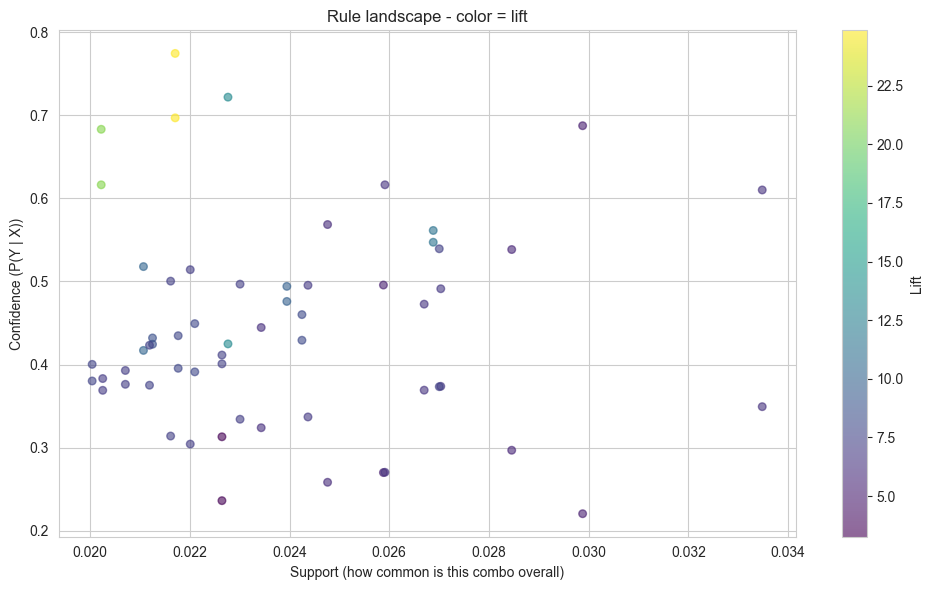

What to look for:
 - Top-right (high support + high confidence) = bestseller bundles
 - Top-left (low support + high confidence + high lift) = niche but reliable
 - The bright yellow/green dots are the highest-lift rules - those are gold for cross-sell


In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(pair_rules['support'], pair_rules['confidence'], c=pair_rules['lift'], cmap='viridis', alpha=0.6, s=30)
ax.set_xlabel('Support (how common is this combo overall)')
ax.set_ylabel('Confidence (P(Y | X))')
ax.set_title('Rule landscape - color = lift')
plt.colorbar(sc, ax=ax, label='Lift')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'basket_rule_landscape.png', dpi=120, bbox_inches='tight')
plt.show()

print('What to look for:')
print(' - Top-right (high support + high confidence) = bestseller bundles')
print(' - Top-left (low support + high confidence + high lift) = niche but reliable')
print(' - The bright yellow/green dots are the highest-lift rules - those are gold for cross-sell')

## 8. Build the cross-sell lookup table

For the recommendation engine, we need a clean lookup: **given a product the customer bought, what are the top N products to recommend?**

This is just pair rules grouped by antecedent, keeping the top recommendations per product, ranked by lift.

In [38]:
# Extract antecedent and consequent as single StockCodes (we filtered to pair rules)
pair_rules['antecedent_code'] = pair_rules['antecedents'].apply(lambda x: list(x)[0])
pair_rules['consequent_code'] = pair_rules['consequents'].apply(lambda x: list(x)[0])

cross_sell = (pair_rules
              .sort_values(['antecedent_code','lift'], ascending=[True, False])
              .groupby('antecedent_code')
              .head(5)  # Top 5 recommendations per product
              [['antecedent_code','consequent_code','antecedent_desc','consequent_desc',
                'support','confidence','lift']]
              .rename(columns={
                  'antecedent_code': 'product_code',
                  'consequent_code': 'recommendation_code',
                  'antesedent_desc': 'product_description',
                  'consequent_desc': 'recommendation_description'
              })
              .reset_index(drop=True))

print(f'Cross-sell table: {len(cross_sell):,} rows ({cross_sell["product_code"].nunique():,} unique products, up to 5 recommendations each)')

# Example: show cross-sell recommendations for a new popular products
sample_products = top_singles.head(5).apply(lambda r: list(r['itemsets'])[0], axis=1).tolist()
for code in sample_products:
  recs = cross_sell[cross_sell['product_code'] == code]
  if len(recs) > 0:
    print(f'\n--- If a customer buys {code} ({desc_lookup.get(code, "")}) ---')
    for _, r in recs.iterrows():
      print(f'  Recommend: {r["recommendation_description"]} (lift {r["lift"]:.2f}x)')

Cross-sell table: 57 rows (30 unique products, up to 5 recommendations each)

--- If a customer buys 85123A (WHITE HANGING HEART T-LIGHT HOLDER) ---
  Recommend: RED HANGING HEART T-LIGHT HOLDER (lift 5.07x)

--- If a customer buys 85099B (JUMBO BAG RED RETROSPOT) ---
  Recommend: JUMBO BAG STRAWBERRY (lift 6.43x)
  Recommend: JUMBO BAG PINK POLKADOT (lift 6.36x)
  Recommend: JUMBO  BAG BAROQUE BLACK WHITE (lift 5.93x)
  Recommend: JUMBO STORAGE BAG SUKI (lift 5.62x)
  Recommend: JUMBO SHOPPER VINTAGE RED PAISLEY (lift 5.17x)

--- If a customer buys 20725 (LUNCH BAG RED RETROSPOT) ---
  Recommend: LUNCH BAG PINK POLKADOT (lift 7.46x)
  Recommend: LUNCH BAG WOODLAND (lift 7.11x)
  Recommend: LUNCH BAG CARS BLUE (lift 6.85x)
  Recommend: LUNCH BAG  BLACK SKULL. (lift 6.79x)
  Recommend: LUNCH BAG SUKI  DESIGN (lift 6.54x)


## 9. Visualize the recommendation network

A graph view of the top rules. Each node = a product, each edge = a high-lift cross-sell rule. Clusters in this graph reveal natural product families.

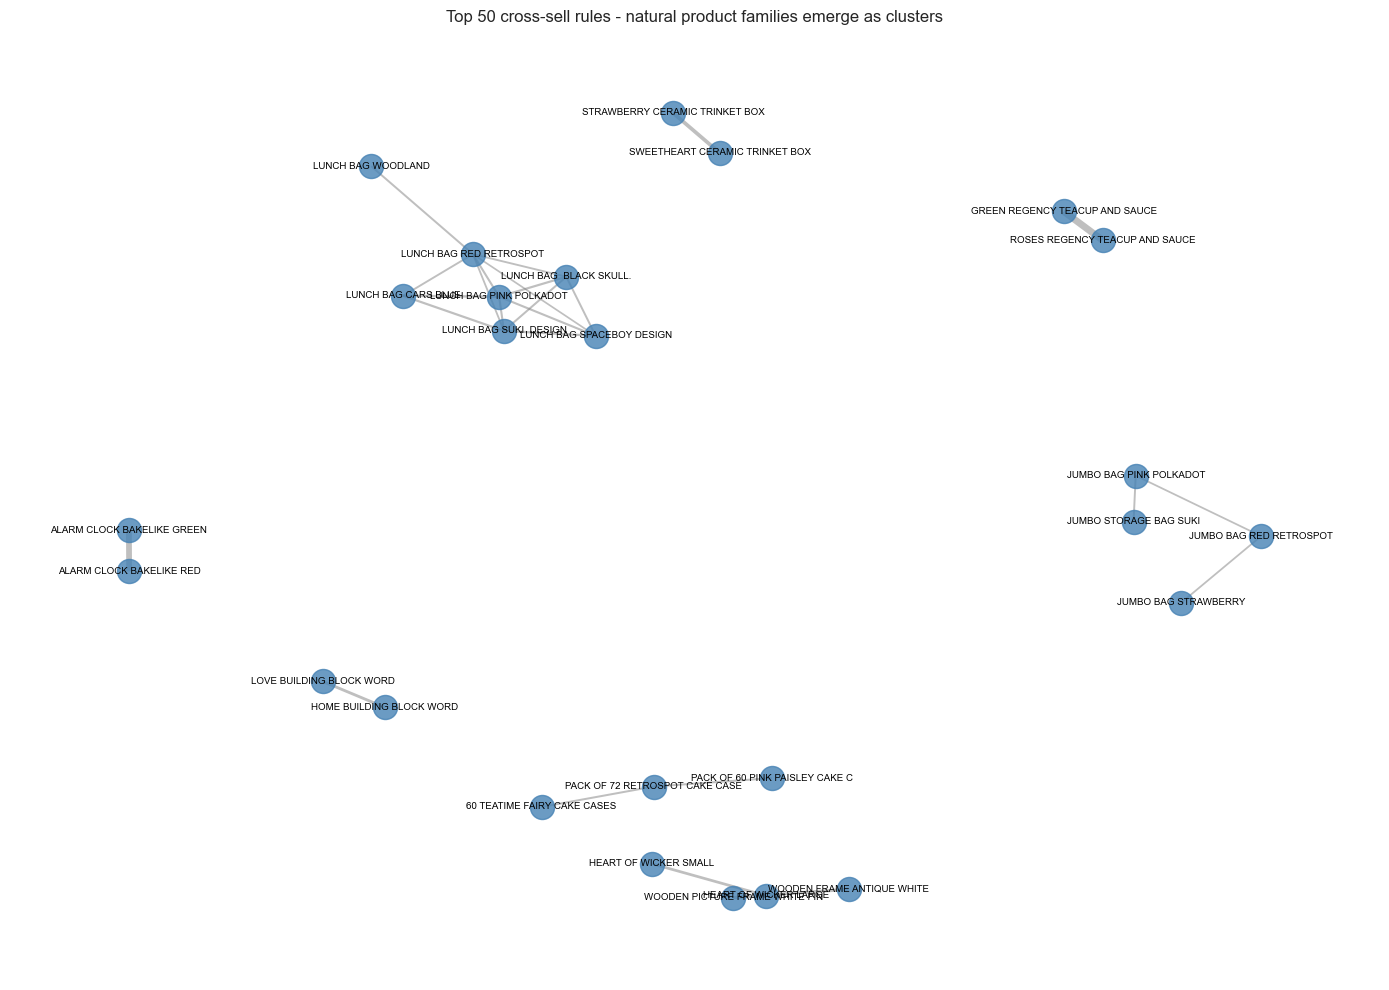

In [40]:
import networkx as nx

# Take top 50 highest-list unique pairs to keep the graph readable
top_pairs = pair_rules.nlargest(50, 'lift').copy()
G = nx.Graph()
for _, r in top_pairs.iterrows():
    a_desc = desc_lookup.get(r['antecedent_code'], r['antecedent_code'])[:30]
    c_desc = desc_lookup.get(r['consequent_code'], r['consequent_code'])[:30]
    G.add_edge(a_desc, c_desc, weight=r['lift'])
    
fig, ax = plt.subplots(figsize=(14,10))
pos = nx.spring_layout(G, k=0.8, seed=42)
edge_widths = [G[u][v]['weight'] / 5 for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='steelblue', alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5, edge_color='gray', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
ax.set_title('Top 50 cross-sell rules - natural product families emerge as clusters')
ax.axis('off')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'basket_network.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Save outputs

In [42]:
# Save full rules table (for any further analysis)
rules_save = rules.drop(columns=['antecedents','consequents']).copy()
rules_path = PROCESSED_DIR / 'product_rules.parquet'
rules_save.to_parquet(rules_path, index=False)
print(f'Rules saved: {rules_path} ({len(rules_save):,} rows)')

# Save the cross-sell lookup (thi is what the recommendation engine uses)
cs_path = PROCESSED_DIR / 'product_cross_sell.parquet'
cross_sell.to_parquet(cs_path, index=False)
print(f'Cross-sell saved: {cs_path} ({len(cross_sell):,} rows)')

# Summary stats for the project documentation
print('\nAnalysis summary:')
print(f'    Invoices analysis:  {basket_binary.shape[0]:,}')
print(f'    Products analysis:  {basket_binary.shape[1]:,}')
print(f'    Frequent itemsets:  {len(frequent_itemsets):,}')
print(f'    Association rules:  {len(rules):,}')
print(f'    Pair rules:         {len(pair_rules):,}')
print(f'    Products with cross-sell desc: {cross_sell["product_code"].nunique():,}')

Rules saved: ../data/processed/product_rules.parquet (60 rows)
Cross-sell saved: ../data/processed/product_cross_sell.parquet (57 rows)

Analysis summary:
    Invoices analysis:  33,032
    Products analysis:  527
    Frequent itemsets:  232
    Association rules:  60
    Pair rules:         60
    Products with cross-sell desc: 30


## Summary

**What we built:**
- Frequent itemsets identifying which products commonly appear together.
- Association rules with support, confidence, and lift.
- A clean cross-sell lookup table: for each popular product, the top 5 highest-lift recommendations.
- A rule landscape visualization and product network graph

**Key design decisions:**
1. **Aggressive filtering** - capped basket size and dropped rare products. Combinatorial space is enormous; you have to focus on where reliable patterns can exist.
2. **Use `transactions_clean` not `customer_level`** - guest checkout still contribute valid co-purchase signal. Customer ID isn't needed for basket analysis.
3. **Rank by lift, not confidence** - confidence rewards bestseller; lift rewards real associations.
4. **`max_len=3`** - pairs and triple are the actionable unit for cross-sell. Bigger itemsets are harder to interpret and rarer.
5. **Save as parquet** - the recommendation (Notebook 08) reads this directly.

**Important limitations to mention:**
- The cross-sell lookup only covers the ~150 most popular products. Rare products won't have recommendations.
- Apriori treats co-occurrence as symmetric - A-then-B and B-then-A are weighted the same. This is fine for cross-sell but doesn't capture sequence ordering.
- Causation is NOT inferred - "customer A who buy A also buy B" doesn't mean offering B will make them buy A. We're identifying patterns, not testing interventions.

**How this connects to the strategy matrix (Notebook 06)**:
- Strategy matrix says: "Customer 12345 is in the Urgent Win-back quadrant.
- Cross-sell lookup says: "Their highest-spend historical product is X. Top recommendations for X are Y and Z."
- Combined: "Send customer 12345 a personalized offer featuring Y (the highest-lift complement to their favorite product X)."

That's a complete, defensible recommendation system. Built without anything more exotic than Apriori from the 1990s and XGBoost - proof that the most valuable ML is often the well-applied basics.

**Next:** Notebook 08 - the recommendation engine. We'll join the strategy matrix, CLV predictions, churn risk, SHAP-driven explanations, AND market basket recommendations into a sinple per-customer JSON output that a marketing system or API could consume directly. That's where everything we've built since Notebook 01 becomes a usable product.